In [22]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation



In [2]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [20]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:00


In [5]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

1. Collect comments

In [14]:
data = [
    "Absolutely love the new smartwatch! Best purchase this year #amazing",
    "Really disappointed with the laptop, broke after two days #fail",
    "Customer service was great, fixed my issue in minutes",
    "Waste of money, nothing like the ad promised",
    "Just got the new headphones, will review after using them",
    "This app is a game changer, thank you!",
    "Terrible experience, my order arrived damaged",
    "Super happy with the quality, highly recommend",
]
df = pd.DataFrame(data, columns=["text"])


2. Clean and preprocess text

In [15]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

3. Sentiment analysis

In [23]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["text"].apply(get_sentiment)
print(df[["text", "sentiment"]])
print("\nSentiment counts:\n", df["sentiment"].value_counts())

                                                text sentiment
0  Absolutely love the new smartwatch! Best purch...  positive
1  Really disappointed with the laptop, broke aft...  negative
2  Customer service was great, fixed my issue in ...  positive
3       Waste of money, nothing like the ad promised  negative
4  Just got the new headphones, will review after...   neutral
5             This app is a game changer, thank you!  positive
6      Terrible experience, my order arrived damaged  negative
7     Super happy with the quality, highly recommend  positive

Sentiment counts:
 sentiment
positive    4
negative    3
neutral     1
Name: count, dtype: int64


4. Trending topics (top keywords)

In [24]:
all_words = " ".join(df["clean_text"]).split()
top_words = Counter(all_words).most_common(10)
print("\nTop keywords:", top_words)


Top keywords: [('the', 5), ('new', 2), ('this', 2), ('with', 2), ('after', 2), ('my', 2), ('absolutely', 1), ('love', 1), ('smartwatch', 1), ('best', 1)]


Topic modeling with LDA

In [25]:
vectorizer = CountVectorizer(max_df=0.9, min_df=1)
dtm = vectorizer.fit_transform(df["clean_text"])
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(dtm)

words = vectorizer.get_feature_names_out()
print("\nTopics:")
for i, topic in enumerate(lda.components_):
    top = [words[j] for j in topic.argsort()[-5:]]
    print(f"Topic {i+1}: {top}")


Topics:
Topic 1: ['using', 'them', 'new', 'after', 'the']
Topic 2: ['smartwatch', 'year', 'with', 'this', 'the']
Topic 3: ['fixed', 'customer', 'in', 'was', 'my']


5. Visualize public opinion

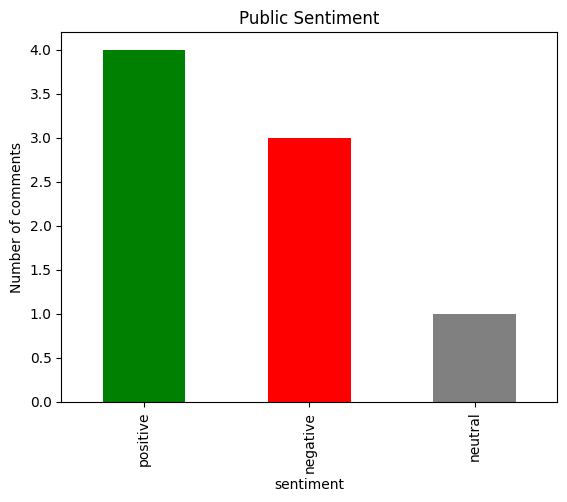

In [26]:
df["sentiment"].value_counts().plot(kind="bar", color=["green", "red", "gray"])
plt.title("Public Sentiment")
plt.ylabel("Number of comments")
plt.savefig("sentiment_chart.png")
plt.show()

Word cloud

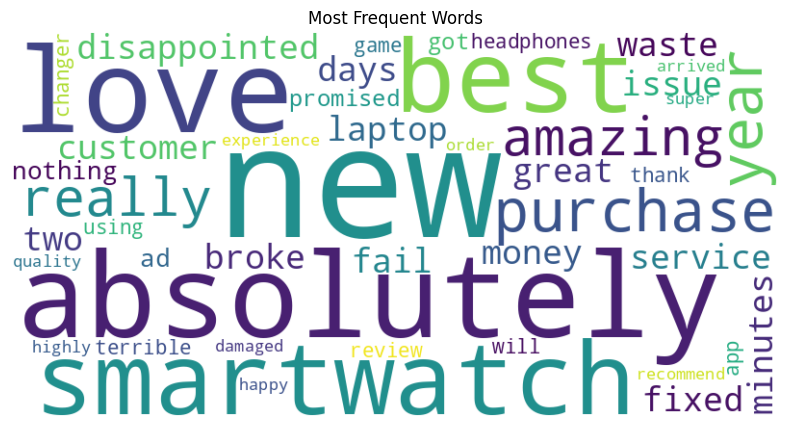

In [27]:
text = " ".join(df["clean_text"])
wc = WordCloud(width=800, height=400, background_color="white").generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words")
plt.savefig("wordcloud.png")
plt.show()